In [1]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")

pd.set_option("display.max_rows", 500)
pd.set_option("display.max_columns", 500)
pd.set_option("display.width", 1000)

# plotting style
plt.style.use("seaborn-v0_8")
sns.set_palette("husl")
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)

In [2]:
to_compare = ["kria_openssl", "kria_swtpm", "kria_tpm", "rpi_openssl", "rpi_swtpm", "ubuntu_openssl", "ubuntu_swtpm"]
processed_path = "./pipeline/data/processed/"

combined_list = []
for file in to_compare:
    if "vm" in file or "ubuntu" in file:
        continue

    try:
        df = pd.read_csv(processed_path + f"{file}.csv")
        print(f"{file}: {df.shape}")

        dev, type_ = file.split("_")
        df["device"] = dev.replace("ubuntu", "vm")
        df["type"] = type_
        df["device_type"] = file.replace("ubuntu", "vm")

        combined_list.append(df)
    except FileNotFoundError:
        continue
    except Exception as err:
        print(str(err))

if combined_list:
    combined_df = pd.concat(combined_list).sort_values(
        by=["run", "image_name", "integrity_check_enabled"], ignore_index=True
    )
else:
    combined_df = pd.DataFrame()

print(f"Combined: {combined_df.shape}")

kria_openssl: (420, 6)
kria_swtpm: (420, 6)
kria_tpm: (420, 6)
rpi_openssl: (420, 6)
rpi_swtpm: (420, 6)
Combined: (2100, 9)


In [3]:
combined_df.head(15)

,run,image_name,integrity_check_enabled,integrity_duration_ms,inference_duration_ms,processing_time_ms,device,type,device_type
0,1,1.jpg,False,0.000,351.862,351.862,kria,openssl,kria_openssl
1,1,1.jpg,False,0.000,343.642,343.642,kria,swtpm,kria_swtpm
2,1,1.jpg,False,0.000,345.123,345.123,kria,tpm,kria_tpm
3,1,1.jpg,False,0.000,198.776,198.776,rpi,openssl,rpi_openssl
4,1,1.jpg,False,0.000,204.510,204.510,rpi,swtpm,rpi_swtpm
5,1,1.jpg,True,99.305,340.780,440.085,kria,openssl,kria_openssl
6,1,1.jpg,True,84.813,385.795,470.608,kria,swtpm,kria_swtpm
7,1,1.jpg,True,312.367,353.003,665.370,kria,tpm,kria_tpm
8,1,1.jpg,True,123.364,205.752,329.116,rpi,openssl,rpi_openssl
9,1,1.jpg,True,117.784,198.349,316.133,rpi,swtpm,rpi_swtpm


In [4]:
summary_stats = (
    combined_df.groupby(["integrity_check_enabled"])
    .agg(
        {
            "integrity_duration_ms": ["mean", "std", "min", "max"],
            "inference_duration_ms": ["mean", "std", "min", "max"],
            "processing_time_ms": ["mean", "std", "min", "max"],
        }
    )
    .round(2)
)
display(summary_stats)

summary_stats = (
    combined_df.groupby(["device_type", "integrity_check_enabled"])
    .agg(
        {
            "integrity_duration_ms": ["mean", "std", "min", "max"],
            "inference_duration_ms": ["mean", "std", "min", "max"],
            "processing_time_ms": ["mean", "std", "min", "max"],
        }
    )
    .round(2)
)
display(summary_stats)

integrity_duration_ms                       inference_duration_ms                          processing_time_ms                         
                                         mean    std    min     max                  mean     std     min      max               mean     std     min      max
integrity_check_enabled                                                                                                                                       
False                                    0.00   0.00   0.00    0.00               1174.62  754.55  198.78  3908.20            1174.62  754.55  198.78  3908.20
True                                   148.66  84.21  84.48  373.38               1178.62  754.17  198.35  3923.51            1327.29  769.31  316.13  4234.02

integrity_duration_ms                        inference_duration_ms                          processing_time_ms                         
                                                      mean    std     min     max                  mean     std     min      max               mean     std     min      max
device_type  integrity_check_enabled                                                                                                                                        
kria_openssl False                                    0.00   0.00    0.00    0.00               1485.02  789.50  344.76  3898.06            1485.02  789.50  344.76  3898.06
             True                                    99.53   1.03   98.94  111.79               1490.51  788.11  340.78  3908.94            1590.04  788.13  440.08  4008.12
kria_swtpm   False                                    0.00   0.00    0.00    0.00               1484.46  790.05  342.34  3908.20            1484.46  790.05  342.34  3908.20
             True                                    84.86   0.60   84.48   92.00               1488.90  787.47  342.01  3923.51            1573.76  787.48  426.89  4008.37
kria_tpm     False                                    0.00   0.00    0.00    0.00               1478.16  785.17  341.65  3896.99            1478.16  785.17  341.65  3896.99
             True                                   313.28   1.73  308.96  328.00               1484.89  783.16  342.55  3921.22            1798.17  783.33  658.46  4234.02
rpi_openssl  False                                    0.00   0.00    0.00    0.00                710.82  372.82  198.78  1988.70             710.82  372.82  198.78  1988.70
             True                                   126.64  19.21  123.25  373.38                713.48  372.67  201.25  1995.09             840.12  374.31  324.88  2119.59
rpi_swtpm    False                                    0.00   0.00    0.00    0.00                714.62  374.22  200.05  1993.10             714.62  374.22  200.05  1993.10
             True                                   119.01  10.04  116.61  189.07                715.33  373.57  198.35  1993.57             834.34  373.84  316.13  2111.11

In [5]:
wi_integrity = combined_df[combined_df["integrity_check_enabled"] == True]
woi_integrity = combined_df[combined_df["integrity_check_enabled"] == False]

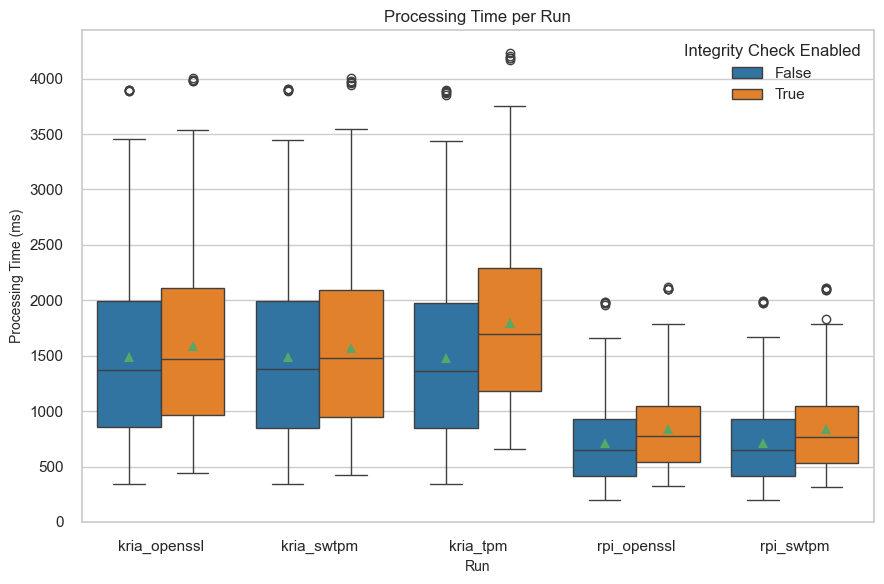

In [6]:
plt.figure(figsize=(9, 6))
# processing time per run
sns.boxplot(
    data=combined_df,
    x="device_type",
    y="processing_time_ms",
    hue="integrity_check_enabled",
    palette="tab10",
    showmeans=True,
    meanprops={"markersize": "7"},
)

plt.title("Processing Time per Run", fontsize=12)
plt.xlabel("Run", fontsize=10)
plt.ylabel("Processing Time (ms)", fontsize=10)
plt.legend(title="Integrity Check Enabled")
plt.tight_layout()
plt.show()

In [9]:
# total processing time
with_integrity_total = wi_integrity["processing_time_ms"]
without_integrity_total = woi_integrity["inference_duration_ms"]

# summary
print("=== Processing Time ===")
with_integrity_mean = with_integrity_total.mean()
without_integrity_mean = without_integrity_total.mean()
time_overhead = with_integrity_mean - without_integrity_mean
time_overhead_pct = (time_overhead / without_integrity_mean) * 100

print(f"Average total processing time with integrity: {with_integrity_mean:.2f} ms")
print(f"Average total processing time without integrity: {without_integrity_mean:.2f} ms")
print(f"Time overhead from integrity check: {time_overhead:.2f} ms ({time_overhead_pct:.1f}%)")
print(f"Average integrity check duration: {wi_integrity['integrity_duration_ms'].mean():.2f} ms")

=== Processing Time ===
Average total processing time with integrity: 1327.29 ms
Average total processing time without integrity: 1174.62 ms
Time overhead from integrity check: 152.67 ms (13.0%)
Average integrity check duration: 148.66 ms
